Import Libraries

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

Load Dataset

In [2]:
df = pd.read_csv('../data/raw/malaysia_house_price_data_2025.csv')
df.head()

,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,363


Checking Tenure for Mixed Values is important or not?

In [3]:
print(df["Tenure"].value_counts())

Tenure
Freehold               1318
Leasehold               624
Freehold, Leasehold      31
Leasehold, Freehold      27
Name: count, dtype: int64


In [4]:
mixed = df[df["Tenure"].str.contains(",")]

print(mixed.shape)
mixed.head(10)

(58, 8)


,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
30,BANDAR BARU KANGKAR PULAI,Kulai,Johor,"Freehold, Leasehold","Cluster House, Terrace House",553200.0,297.0,155
106,BANDAR BARU UDA,Johor Bahru,Johor,"Leasehold, Freehold",Terrace House,500000.0,279.0,78
146,BANDAR SERI BOTANI,Ipoh,Perak,"Freehold, Leasehold","Terrace House, Semi D",496800.0,344.0,67
171,TAMAN SAMARINDAH,Kota Samarahan,Sarawak,"Freehold, Leasehold",Terrace House,300000.0,168.0,59
201,KUALA BERANG,Hulu Terengganu,Terengganu,"Freehold, Leasehold","Bungalow, Terrace House",200000.0,62.0,53
232,TAMAN CEMPAKA,Ipoh,Perak,"Freehold, Leasehold",Terrace House,199000.0,202.0,49
236,KEPONG BARU,Kepong,Kuala Lumpur,"Leasehold, Freehold",Terrace House,667500.0,445.0,48
274,TAMAN BUKIT DAHLIA,Pasir Gudang,Johor,"Freehold, Leasehold",Terrace House,480000.0,353.0,43
297,BANDAR SERI BOTANI,Simpang Pulai,Perak,"Freehold, Leasehold",Terrace House,448800.0,288.0,40
300,TAMAN CANNING,Ipoh,Perak,"Freehold, Leasehold","Terrace House, Semi D, Bungalow",425000.0,171.0,39


In [5]:
mixed = df[df["Tenure"].str.contains(",")]

print(mixed["Type"].value_counts())

Type
Terrace House                      39
Bungalow, Terrace House             3
Semi D, Terrace House               3
Terrace House, Semi D               2
Terrace House, Bungalow             2
Cluster House, Terrace House        1
Terrace House, Semi D, Bungalow     1
Service Residence                   1
Terrace House, Town House           1
Apartment                           1
Town House, Bungalow                1
Cluster House                       1
Terrace House, Cluster House        1
Bungalow, Semi D                    1
Name: count, dtype: int64


In [6]:
print(mixed["State"].value_counts())

State
Selangor           16
Johor              10
Perak              10
Melaka              7
Sarawak             4
Terengganu          3
Negeri Sembilan     3
Kuala Lumpur        2
Pahang              2
Penang              1
Name: count, dtype: int64


In [50]:
print(mixed["Area"].value_counts())

Area
Ipoh                                 6
Skudai                               3
Puchong                              3
Johor Bahru                          2
Kerteh                               2
Petaling Jaya                        2
Dengkil                              2
Kuching                              2
Bertam                               2
Kulai                                1
Kota Samarahan                       1
Hulu Terengganu                      1
Kepong                               1
Pasir Gudang                         1
Simpang Pulai                        1
Jalan Klang Lama (Old Klang Road)    1
Bukit Rambai                         1
Balai Panjang                        1
Klang                                1
Butterworth                          1
Bidor                                1
Pengerang                            1
Sungai Buloh                         1
Kuantan                              1
Parit Buntar                         1
Seri Kembangan      

## Clean Tenure

Combine **Freehold, Leasehold** and **Leasehold, Freehold** into **Freehold and Leasehold** as they represent the same tenure type.

In [7]:
df["Tenure"] = df["Tenure"].replace({
    "Freehold, Leasehold": "Freehold and Leasehold",
    "Leasehold, Freehold": "Freehold and Leasehold",
})

Verify the changes

In [8]:
print(df["Tenure"].value_counts())

Tenure
Freehold                  1318
Leasehold                  624
Freehold and Leasehold      58
Name: count, dtype: int64


In [9]:
def normalize_type(x):
    types = [t.strip() for t in x.split(",")]
    types = sorted(types)
    return ", ".join(types)

df["Type"] = df["Type"].apply(normalize_type)

In [10]:
print(df["Type"].value_counts())

Type
Terrace House                               956
Apartment                                   197
Semi D, Terrace House                       182
Condominium                                 167
Flat                                        131
Service Residence                            96
Cluster House, Terrace House                 55
Bungalow, Terrace House                      44
Semi D                                       43
Cluster House                                24
Bungalow, Semi D                             22
Terrace House, Town House                    16
Bungalow, Semi D, Terrace House              13
Bungalow                                     13
Cluster House, Semi D                        10
Semi D, Terrace House, Town House             7
Town House                                    7
Cluster House, Semi D, Terrace House          4
Apartment, Flat                               3
Bungalow, Town House                          2
Semi D, Town House                 

### Multi-label Encoding

In [11]:
type_dummies = df["Type"].str.get_dummies(sep=", ")

In [12]:
type_dummies.head()

,Apartment,Bungalow,Cluster House,Condominium,Flat,Semi D,Service Residence,Terrace House,Town House
0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0


### Drop and combine a new DataFrame

In [13]:
df = pd.concat(
    [df.drop(columns=["Type"]), type_dummies],
    axis=1
)

In [14]:
df.head()

,Township,Area,State,Tenure,Median_Price,Median_PSF,Transactions,Apartment,Bungalow,Cluster House,Condominium,Flat,Semi D,Service Residence,Terrace House,Town House
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,331800.0,304.0,593,0,0,0,0,0,0,0,1,0
1,BANDAR PUTRA,Kulai,Johor,Freehold,590900.0,322.0,519,0,0,1,0,0,0,0,1,0
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,229954.0,130.0,414,0,0,0,0,0,0,0,1,0
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,255600.0,218.0,391,0,0,0,0,0,0,0,1,0
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,219300.0,168.0,363,0,0,0,0,0,0,0,1,0


In [15]:
df.iloc[:5, -9:]

,Apartment,Bungalow,Cluster House,Condominium,Flat,Semi D,Service Residence,Terrace House,Town House
0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0


## Feature cleaning
Drop Township (because have 1946 unique data) - 0.28 data is no unique

In [16]:
df = df.drop(columns=["Township"])

In [61]:
#df = df.drop(columns=["Area"]) # try this later

In [17]:
print(df.columns)

Index(['Area', 'State', 'Tenure', 'Median_Price', 'Median_PSF', 'Transactions',
       'Apartment', 'Bungalow', 'Cluster House', 'Condominium', 'Flat',
       'Semi D', 'Service Residence', 'Terrace House', 'Town House'],
      dtype='str')


In [18]:
area_counts = df["Area"].value_counts()
print(area_counts.describe())

count    303.000000
mean       6.600660
std        9.075599
min        1.000000
25%        2.000000
50%        3.000000
75%        7.000000
max       67.000000
Name: count, dtype: float64


In [19]:
print((area_counts == 1).sum())   # 1 Area
print((area_counts == 2).sum())   # 2 Area
print((area_counts == 3).sum())   # 3 Area
print((area_counts == 6).sum())

74
52
26
14


## One-Hot Encoding for Area, State, and Tenure

In [20]:
categorical_cols = ["Area", "State", "Tenure"]

In [21]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    dtype=int
)

In [22]:
print(df.shape)
print(df.head())
print(df.columns)

(2000, 334)
   Median_Price  Median_PSF  Transactions  Apartment  Bungalow  Cluster House  \
0      331800.0       304.0           593          0         0              0   
1      590900.0       322.0           519          0         0              1   
2      229954.0       130.0           414          0         0              0   
3      255600.0       218.0           391          0         0              0   
4      219300.0       168.0           363          0         0              0   

   Condominium  Flat  Semi D  Service Residence  ...  State_Perak  \
0            0     0       0                  0  ...            0   
1            0     0       0                  0  ...            0   
2            0     0       0                  0  ...            1   
3            0     0       0                  0  ...            0   
4            0     0       0                  0  ...            1   

   State_Perlis  State_Putrajaya  State_Sabah  State_Sarawak  State_Selangor  \
0     

In [23]:
print(df.filter(regex="Tenure_").head())

   Tenure_Freehold  Tenure_Freehold and Leasehold  Tenure_Leasehold
0                1                              0                 0
1                1                              0                 0
2                1                              0                 0
3                1                              0                 0
4                0                              0                 1


Plot diagram to check Target Median_Price has Skewed

<Axes: xlabel='Median_Price', ylabel='Count'>

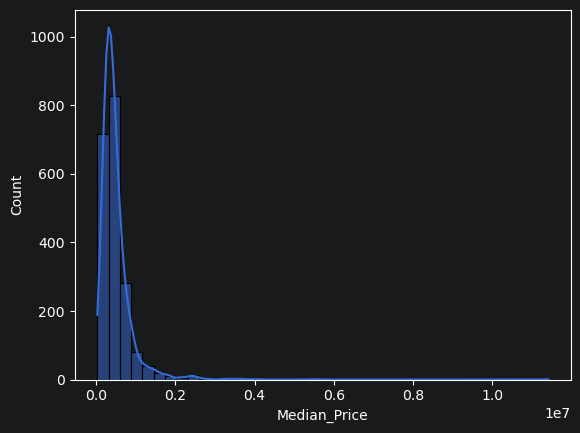

In [24]:
sns.histplot(df["Median_Price"], bins=40, kde=True)

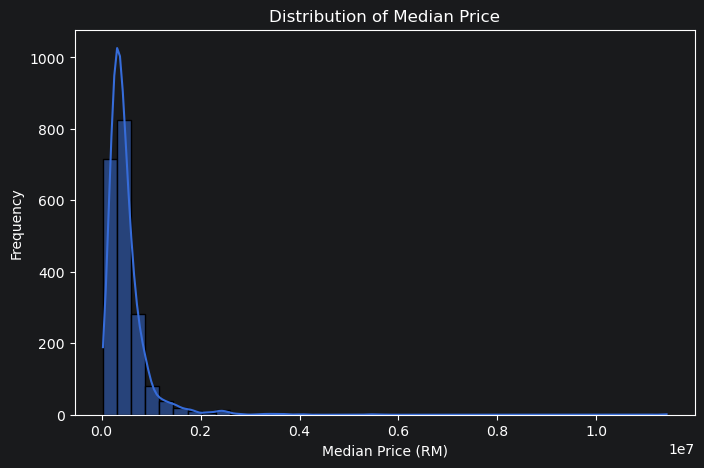

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(df["Median_Price"], bins=40, kde=True)

plt.title("Distribution of Median Price")
plt.xlabel("Median Price (RM)")
plt.ylabel("Frequency")

plt.show()

In [71]:
print(df["Median_Price"].skew())

8.826322818971828


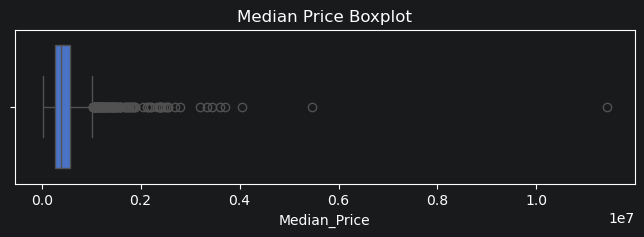

In [25]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["Median_Price"])

plt.title("Median Price Boxplot")

plt.show()

## Feature and Target Visualization

In [26]:
# Target
y = df["Median_Price"]

# Features
X = df.drop(columns=["Median_Price"])

In [27]:
print(X.shape)
print(y.shape)

(2000, 333)
(2000,)


In [28]:
print(X.shape)
print(X.dtypes.value_counts())

(2000, 333)
int32      322
int64       10
float64      1
Name: count, dtype: int64


Check constant Features

In [29]:
selector = VarianceThreshold(threshold=0)

selector.fit(X)

print("Original Features:", X.shape[1])
print("Remaining Features:", selector.get_support().sum())

Original Features: 333
Remaining Features: 333


In [30]:
corr = X.corr(numeric_only=True)

In [31]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(abs(upper[column]) > 0.95)
]

print(high_corr)

['State_Labuan', 'State_Perlis', 'State_Putrajaya']


In [32]:
X = df.drop(columns=["Median_Price"])
y = df["Median_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 333)
(400, 333)


XGBoost first time training - Baseline Model

In [80]:
model = XGBRegressor(
    random_state=42
)

Model Training

In [81]:
model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Prediction

In [82]:
y_pred = model.predict(X_test)

Evaluation

In [83]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 128346.26551574707
RMSE: 373081.1420834034
R²  : 0.20878745235893104


Features Importance

In [38]:
importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.tail(300)

,Feature,Importance
249,Area_Setia Alam,0.001191
83,Area_Desa ParkCity,0.001178
209,Area_Permas Jaya,0.001106
44,Area_Batu Caves,0.001041
135,Area_Klang,0.001035
...,...,...
108,Area_Jalan Ipoh,0.000000
122,Area_KL Sentral,0.000000
210,Area_Permatang Pauh,0.000000
73,Area_Cheng,0.000000


Plot the Features Importance

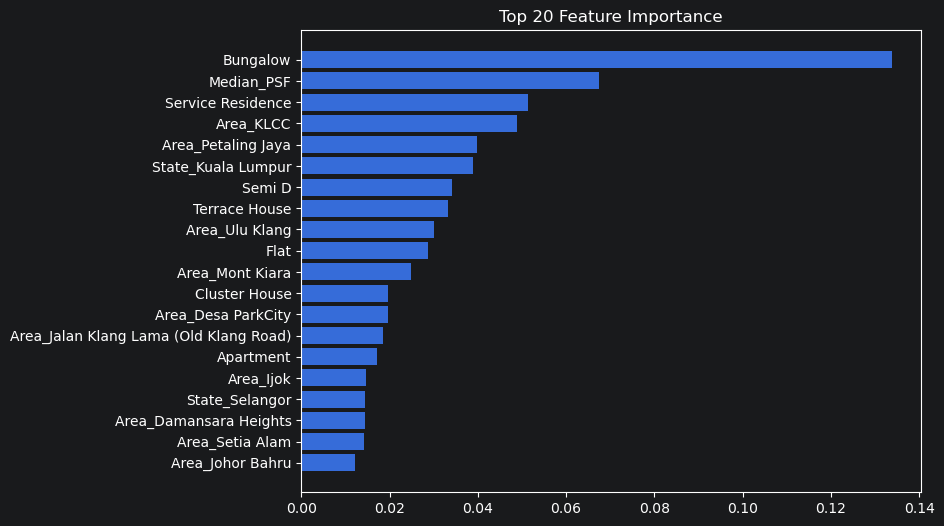

In [85]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(8,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importance")

plt.show()

In [36]:
print(df.columns.tolist())

['Median_Price', 'Median_PSF', 'Transactions', 'Apartment', 'Bungalow', 'Cluster House', 'Condominium', 'Flat', 'Semi D', 'Service Residence', 'Terrace House', 'Town House', 'Area_Alor Gajah', 'Area_Alor Setar', 'Area_Ampang', 'Area_Ampang Hilir', 'Area_Ampangan', 'Area_Ara Damansara', 'Area_Arau', 'Area_Ayer Itam', 'Area_Ayer Molek', 'Area_Bachang', 'Area_Bagan Serai', 'Area_Bahau', 'Area_Bakri', 'Area_Balai Panjang', 'Area_Balakong', 'Area_Balik Pulau', 'Area_Bandar Baharu', 'Area_Bandar Enstek', 'Area_Bandar Kinrara', 'Area_Bandar Menjalara', 'Area_Bandar Puncak Alam', 'Area_Bandar Sri Damansara', 'Area_Bandar Sri Sendayan', 'Area_Bandar Sungai Long', 'Area_Bandar Sunway', 'Area_Bandar Tasik Selatan', 'Area_Bandar Utama', 'Area_Bangi', 'Area_Bangsar', 'Area_Banting', 'Area_Batang Kali', 'Area_Batu Arang', 'Area_Batu Berendam', 'Area_Batu Caves', 'Area_Batu Ferringhi', 'Area_Batu Gajah', 'Area_Batu Kawan', 'Area_Batu Kurau', 'Area_Batu Pahat', 'Area_Bayan Baru', 'Area_Bayan Lepas', '

In [87]:
print(df[["Median_Price","Median_PSF"]].corr())

              Median_Price  Median_PSF
Median_Price      1.000000    0.746647
Median_PSF        0.746647    1.000000


In [37]:
print(X.columns[:5])

Index(['Median_PSF', 'Transactions', 'Apartment', 'Bungalow', 'Cluster House'], dtype='str')
